# Set data directory

In [1]:
path = './data/'

# Preamble

Install the necessary packages:

In [2]:
"""
%pip install tol-colors
%pip install git@github.com:imagdau/aseMolec.git
%pip install ase
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install pyyaml
%pip install scipy
%pip install requests
%pip install pathlib
%pip install joblib
"""

'\n%pip install tol-colors\n%pip install git@github.com:imagdau/aseMolec.git\n%pip install ase\n%pip install pandas\n%pip install numpy\n%pip install matplotlib\n%pip install pyyaml\n%pip install scipy\n%pip install requests\n%pip install pathlib\n%pip install joblib\n'

In [3]:
import funcs as funcs
from ase.io import read, iread
import ase.units
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from aseMolec import pltProps as pp
from aseMolec import anaAtoms as aa
import pandas as pd
import numpy as np
import tol_colors as tc
cset = tc.tol_cset('bright')
plt.rc('axes', prop_cycle=plt.cycler('color', list(cset)))

small_pkl = './clusters-small_xyz.pkl'
medium_pkl = './clusters-medium_xyz.pkl'
large_pkl = './clusters-large_xyz.pkl'

scale = 1.5
fsize = 8*scale
plt.rcParams.update({'font.size': fsize})

/tmp/ipykernel_2184572/436061676.py:12: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('bright')


# Download
## MLIP data
MLIP data refers to training data, trained MLIPs and associated files.

In [4]:
funcs.download_unpack(path, "clusters_metadata.yaml", "MLIP downloads")

./data/MLIP_MACE_Clusters-Small_B97D3.zip
Unzipping ./data/MLIP_MACE_Clusters-Small_B97D3.zip -> ./data/Clusters-Small/B97D3


./data/MLIP_MACE_Clusters-Small_wB97XD3.zip
Unzipping ./data/MLIP_MACE_Clusters-Small_wB97XD3.zip -> ./data/Clusters-Small/wB97XD3


./data/MLIP_MACE_Clusters-Medium_B97D3.zip
Unzipping ./data/MLIP_MACE_Clusters-Medium_B97D3.zip -> ./data/Clusters-Medium/B97D3


./data/MLIP_MACE_Clusters-Medium_wB97XD3.zip
Unzipping ./data/MLIP_MACE_Clusters-Medium_wB97XD3.zip -> ./data/Clusters-Medium/wB97XD3


./data/MLIP_MACE_Clusters-Large_wB97XD3.zip
Unzipping ./data/MLIP_MACE_Clusters-Large_wB97XD3.zip -> ./data/Clusters-Large/wB97XD3


## Data overview

In [5]:
meta_df = funcs.yaml_to_multidf("clusters_metadata.yaml", ["Labels", "Parent data", "Data set"])
meta_df

Subset  Seeds  Number of structures  \
Labels   Parent data     Data set                                               
wB97X-D3 Clusters-Full   Clusters-Large        1      3                221824   
         Clusters-Large  Clusters-Medium       1      3                 42824   
                         Clusters-Medium       2      1                 42824   
                         Clusters-Medium       3      1                 42824   
         Clusters-Medium Clusters-Small        1      3                  8016   
                         Clusters-Small        2      1                  8016   
                         Clusters-Small        3      1                  8016   
B97-D3   Clusters-Large  Clusters-Medium       1      1                 42824   
                         Clusters-Medium       2      1                 42824   
                         Clusters-Medium       3      1                 42824   
         Clusters-Medium Clusters-Small        1      1                  8016   
                         Clusters-Small        2      1                  8016   
                         Clusters-Small        3      1                  8016   

                                          Number of atoms  
Labels   Parent data     Data set                          
wB97X-D3 Clusters-Full   Clusters-Large           4805916  
         Clusters-Large  Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
         Clusters-Medium Clusters-Small            327089  
                         Clusters-Small            327089  
                         Clusters-Small            327089  
B97-D3   Clusters-Large  Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
         Clusters-Medium Clusters-Small            327089  
                         Clusters-Small            327089  
                         Clusters-Small            327089

# Dataset statistics

## Small clusters dataset
Store xyz-data in a pickle file for faster access (may take a while to run):

In [6]:
import pickle
from ase.io import read
from pathlib import Path

if not Path(small_pkl).exists():
    clusters_small_1 = read(f'{path}Clusters-Small/wB97XD3/SEED1/DSET1/training/SD22NQQ1_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
    clusters_small_2 = read(f'{path}Clusters-Small/wB97XD3/SEED1/DSET2/training/SD22NQQ2_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
    clusters_small_3 = read(f'{path}Clusters-Small/wB97XD3/SEED1/DSET3/training/SD22NQQ3_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms

    xyz_dict = {'Clusters-Small-1':clusters_small_1, 'Clusters-Small-2':clusters_small_2, 'Clusters-Small-3':clusters_small_3}
    with open(small_pkl, 'wb') as f:
        pickle.dump(xyz_dict, f)

    num_atoms_small = sum([len(a.numbers) for a in clusters_small_1])

### Cluster composition
Read pickled data:

In [7]:
import pickle

with open(small_pkl, 'rb') as f:
    clusters_small_dict = pickle.load(f)

Cluster distributions:

In [8]:
clusters_small_histograms = funcs.get_mol_histograms(clusters_small_dict)
clusters_small_df = funcs.hist_dict_to_df(clusters_small_histograms)

Show output:

In [9]:
hist_df = clusters_small_df.copy()
hist_df.loc['Total']= hist_df.sum()
hist_df

,Clusters-Small-1,Clusters-Small-2,Clusters-Small-3
"Cluster size, Nmols",,,
1,900,900,900
2,1470,1470,1470
3,2001,2001,2001
4,1917,1917,1917
5,1464,1464,1464
6,264,264,264
Total,8016,8016,8016


### Molecular composition
Molecular dustribution:

In [10]:
data = 'Clusters-Small-1'
print(f'{data}:')
comp = funcs.collect_comp(clusters_small_dict[data])
clusters_small_1_comp = funcs.flatten_comp(comp)
clusters_small_1_comp

Clusters-Small-1:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,150,150,0,0,600
2,70,70,70,560,700
3,40,40,220,1073,628
4,41,200,189,706,781
5,25,322,139,344,634
6,0,0,144,110,10


In [11]:
data = 'Clusters-Small-2'
print(f'{data}:')
comp = funcs.collect_comp(clusters_small_dict[data])
clusters_small_2_comp = funcs.flatten_comp(comp)
clusters_small_2_comp

Clusters-Small-2:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,150,150,0,0,600
2,70,70,70,560,700
3,40,40,220,1073,628
4,41,200,189,706,781
5,25,322,139,344,634
6,0,0,144,110,10


In [12]:
data = 'Clusters-Small-3'
print(f'{data}:')
comp = funcs.collect_comp(clusters_small_dict[data])
clusters_small_3_comp = funcs.flatten_comp(comp)
clusters_small_3_comp

Clusters-Small-3:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,150,150,0,0,600
2,70,70,70,560,700
3,40,40,220,1073,628
4,41,200,189,706,781
5,25,322,139,344,634
6,0,0,144,110,10


## Medium clusters dataset
Store xyz-data in a pickle file for faster access (may take a while to run):

In [13]:
import pickle
from ase.io import read
from pathlib import Path

if not Path(medium_pkl).exists():
    clusters_medium_1 = read(f'{path}Clusters-Medium/wB97XD3/SEED1/DSET1/training/SD22NQ1_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
    clusters_medium_2 = read(f'{path}Clusters-Medium/wB97XD3/SEED1/DSET2/training/SD22NQ2_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
    clusters_medium_3 = read(f'{path}Clusters-Medium/wB97XD3/SEED1/DSET3/training/SD22NQ3_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms

    xyz_dict = {'Clusters-Medium-1':clusters_medium_1, 'Clusters-Medium-2':clusters_medium_2, 'Clusters-Medium-3':clusters_medium_3}
    with open(medium_pkl, 'wb') as f:
        pickle.dump(xyz_dict, f)

    num_atoms_medium = sum([len(a.numbers) for a in clusters_medium_1])

### Cluster composition
Read pickled data:

In [14]:
import pickle

with open(medium_pkl, 'rb') as f:
    clusters_medium_dict = pickle.load(f)

Cluster distribtution:

In [15]:
clusters_medium_histograms = funcs.get_mol_histograms(clusters_medium_dict)
clusters_medium_df = funcs.hist_dict_to_df(clusters_medium_histograms)

Show output:

In [16]:
hist_df = clusters_medium_df.copy()
hist_df.loc['Total']= hist_df.sum()
hist_df

,Clusters-Medium-1,Clusters-Medium-2,Clusters-Medium-3
"Cluster size, Nmols",,,
1,7878,7880,7880
2,18252,18253,18253
3,10176,10176,10176
4,4787,4787,4787
5,1464,1464,1464
6,264,264,264
Total,42821,42824,42824


### Molecular composition
Molecular dustribution:

In [17]:
data = 'Clusters-Medium-1'
print(f'{data}:')
comp = funcs.collect_comp(clusters_medium_dict[data])
clusters_medium_1_comp = funcs.flatten_comp(comp)
clusters_medium_1_comp

Clusters-Medium-1:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,886,2354,0,0,4638
2,1069,190,1092,9087,6814
3,178,1091,516,2433,5958
4,41,1528,189,706,2323
5,25,322,139,344,634
6,0,0,144,110,10


In [18]:
data = 'Clusters-Medium-2'
print(f'{data}:')
comp = funcs.collect_comp(clusters_medium_dict[data])
clusters_medium_2_comp = funcs.flatten_comp(comp)
clusters_medium_2_comp

Clusters-Medium-2:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,887,2354,0,0,4639
2,1069,190,1092,9088,6814
3,178,1091,516,2433,5958
4,41,1528,189,706,2323
5,25,322,139,344,634
6,0,0,144,110,10


In [19]:
data = 'Clusters-Medium-3'
print(f'{data}:')
comp = funcs.collect_comp(clusters_medium_dict[data])
clusters_medium_3_comp = funcs.flatten_comp(comp)
clusters_medium_3_comp

Clusters-Medium-3:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,887,2354,0,0,4639
2,1069,190,1092,9088,6814
3,178,1091,516,2433,5958
4,41,1528,189,706,2323
5,25,322,139,344,634
6,0,0,144,110,10


## Large clusters dataset
Store xyz-data in a pickle file for faster access (may take a while to run):

In [20]:
import pickle
from ase.io import read
from pathlib import Path

if not Path(large_pkl).exists():
    clusters_large = read(f'{path}Clusters-Large/wB97XD3/SEED1/DSET1/training/SD22N_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms

    xyz_dict = {'Clusters-Large':clusters_large}
    with open(large_pkl, 'wb') as f:
        pickle.dump(xyz_dict, f)

    num_atoms_large = sum([len(a.numbers) for a in clusters_large])

### Cluster composition
Read pickled data:

In [21]:
import pickle

with open(large_pkl, 'rb') as f:
    clusters_large_dict = pickle.load(f)

Cluster distributions:

In [22]:
clusters_large_histograms = funcs.get_mol_histograms(clusters_large_dict)
clusters_large_df = funcs.hist_dict_to_df(clusters_large_histograms)

Show output:

In [23]:
hist_df = clusters_large_df.copy()
hist_df.loc['Total']= hist_df.sum()
hist_df

,Clusters-Large
"Cluster size, Nmols",
1,77878
2,82252
3,37176
4,17787
5,6464
6,264
Total,221821


### Molecular composition
Molecular dustribution:

In [24]:
data = 'Clusters-Large'
print(f'{data}:')
comp = funcs.collect_comp(clusters_large_dict[data])
clusters_large_comp = funcs.flatten_comp(comp)
clusters_large_comp

Clusters-Large:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,887,72353,0,0,4638
2,1069,40189,1092,9088,30814
3,178,23091,516,2433,10958
4,41,11528,189,706,5323
5,25,5322,139,344,634
6,0,0,144,110,10


## Overall statistics

### Expected cluster sizes

In [25]:
dfs = {
    'Clusters-Small':clusters_small_df['Clusters-Small-1'],
    'Clusters-Medium':clusters_medium_df['Clusters-Medium-1'],
    'Clusters-Large':clusters_large_df['Clusters-Large'],
}
stats_df = pd.concat(dfs.values(), axis=1, keys=dfs.keys())
expectation = funcs.get_expectation_values(stats_df, stats_df.index.to_numpy())
variance = funcs.get_expectation_values(stats_df, stats_df.index.to_numpy()**2) - expectation**2
stats_df

,Clusters-Small,Clusters-Medium,Clusters-Large
"Cluster size, Nmols",,,
1,900,7878,77878
2,1470,18252,82252
3,2001,10176,37176
4,1917,4787,17787
5,1464,1464,6464
6,264,264,264


Expected cluster sizes:

In [26]:
clusters_small_avg, clusters_medium_avg, clusters_large_avg = expectation
expectation

Clusters-Small     3.30
Clusters-Medium    2.40
Clusters-Large     2.07
dtype: float64

Clsuter size variance:

In [27]:
variance

Clusters-Small     1.7800
Clusters-Medium    1.1300
Clusters-Large     1.1151
dtype: float64

### Visual distributions

/tmp/ipykernel_2184572/2487802461.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[-1].set_ylim([0,1e6])


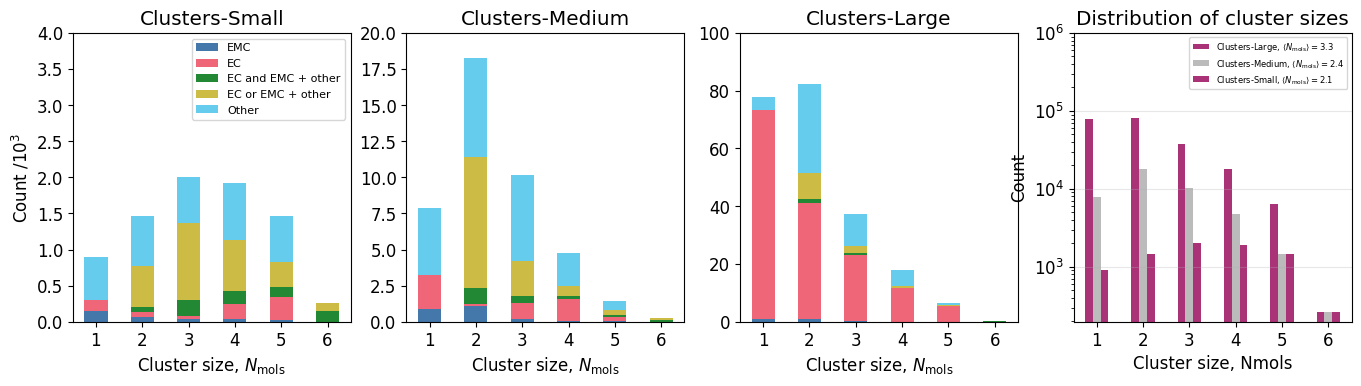

In [28]:
#fsize = 26
#plt.rcParams.update({'font.size': fsize})

fig, axs = plt.subplots(1,4, figsize=(11*scale, 2.5*scale), sharey=False)
comps = {
    'Clusters-Small':clusters_small_1_comp,
    'Clusters-Medium':clusters_medium_1_comp,
    'Clusters-Large':clusters_large_comp,
}

axs = axs.ravel()
for i, (ax, (name, data)) in enumerate(zip(axs, comps.items())):
    d = data/1e3
    if i == 0:
        ax.set_ylim([0,4])
    elif i == 1:
        ax.set_ylim([0,20])
    elif i == 2:
        ax.set_ylim([0,100])

    d.plot.bar(ax=ax, legend=False, stacked=True, rot=0)
    if i == 0: ax.legend(fontsize=fsize-4, ncols=1)
    ax.set_title(name)

    if i == 0: ax.set_ylabel('Count /$10^3$')
    ax.set_xlabel('Cluster size, $N_\\text{mols}$')

axs[-1].set_title('Distribution of cluster sizes')
scaled_stats_df = stats_df
scaled_stats_df[['Clusters-Large', 'Clusters-Medium', 'Clusters-Small']].plot.bar(
    ylabel='Count',
	rot=0,
	ax=axs[-1],
    color=cset[5:],
)
axs[-1].set_yscale('log')
axs[-1].set_ylim([0,1e6])

axs[-1].grid(axis='y', alpha=0.3)
axs[-1].legend(
    [
        f'Clusters-Large, $\\langle N_\\text{{mols}} \\rangle = {clusters_small_avg:.1f}$',
        f'Clusters-Medium, $\\langle N_\\text{{mols}} \\rangle = {clusters_medium_avg:.1f}$',
        f'Clusters-Small, $\\langle N_\\text{{mols}} \\rangle = {clusters_large_avg:.1f}$',
    ],
    fontsize=fsize-6,
)